# 04_osteo_baseline_entrenamiento

Objetivo:
- entrenar un baseline para Osteoarthritis,
- usar ResNet34 preentrenada,
- aplicar CrossEntropyLoss con class weights,
- usar early stopping para evitar entrenar de más,
- guardar checkpoint, historial y métricas finales.

## Imports y rutas

In [1]:
from pathlib import Path
import json
import random
import time
from copy import deepcopy

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path("/mnt/d/Universidad/analitica/proyecto_analitica2")
DATA_DIR = PROJECT_ROOT / "data"
WORKING_DIR = DATA_DIR / "working"
MANIFESTS_DIR = DATA_DIR / "manifests"

DATASET_NAME = "osteo"
META_DIR = WORKING_DIR / DATASET_NAME / "meta"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / f"{DATASET_NAME}_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ACTIVE_SUBSET_PATH = META_DIR / f"{DATASET_NAME}_active_subset.csv"
LABEL_MAP_PATH = META_DIR / f"{DATASET_NAME}_label_map.json"
CLASS_WEIGHTS_PATH = META_DIR / f"{DATASET_NAME}_class_weights.pt"

print("ACTIVE_SUBSET_PATH:", ACTIVE_SUBSET_PATH)
print("LABEL_MAP_PATH:", LABEL_MAP_PATH)
print("CLASS_WEIGHTS_PATH:", CLASS_WEIGHTS_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

ACTIVE_SUBSET_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/meta/osteo_active_subset.csv
LABEL_MAP_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/meta/osteo_label_map.json
CLASS_WEIGHTS_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/meta/osteo_class_weights.pt
OUTPUT_DIR: /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/osteo_baseline


## Configuración de entrenamiento 

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_WORKERS = 4
PIN_MEMORY = True

USE_CLAHE = True
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

USE_TRAIN_AUG = True

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

MODEL_NAME = "resnet34"
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 25

USE_MIXED_PRECISION = True
EARLY_STOPPING_PATIENCE = 6
EARLY_STOPPING_MIN_DELTA = 1e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("USE_MIXED_PRECISION:", USE_MIXED_PRECISION)

DEVICE: cuda
USE_MIXED_PRECISION: True


## Cargar datos base

In [3]:
df = pd.read_csv(ACTIVE_SUBSET_PATH)

with open(LABEL_MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

label_to_idx = label_map["label_to_idx"]
idx_to_label = {int(k): v for k, v in label_map["idx_to_label"].items()}

class_weights = torch.load(CLASS_WEIGHTS_PATH, map_location="cpu")

print("Shape df:", df.shape)
print("label_to_idx:", label_to_idx)
print("idx_to_label:", idx_to_label)
print("class_weights:", class_weights)
display(df.head())

Shape df: (4766, 8)
label_to_idx: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
idx_to_label: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4'}
class_weights: tensor([0.7244, 0.7530, 1.2471, 1.2831, 1.4076])


,image_id,filename,file_path,label_text,target_label,split,source_dataset,subset_name
0,SevereG4 (233),SevereG4 (233).png,/mnt/d/Universidad/analitica/proyecto_analitic...,4,4,train,osteo,large
1,grade_2_164_png.rf.cf42a3f0b781d99bc4c5c408c8c...,grade_2_164_png.rf.cf42a3f0b781d99bc4c5c408c8c...,/mnt/d/Universidad/analitica/proyecto_analitic...,2,2,train,osteo,large
2,MildG2 (232),MildG2 (232).png,/mnt/d/Universidad/analitica/proyecto_analitic...,2,2,train,osteo,large
3,NormalG0 (64),NormalG0 (64).png,/mnt/d/Universidad/analitica/proyecto_analitic...,0,0,val,osteo,large
4,MildG2 (144),MildG2 (144).png,/mnt/d/Universidad/analitica/proyecto_analitic...,2,2,train,osteo,large


## Separar train / val / test

In [4]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df = df[df["split"] == "test"].copy().reset_index(drop=True)

print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

train_df: (3336, 8)
val_df: (715, 8)
test_df: (715, 8)


## OpenCV para CLAHE

In [5]:
try:
    import cv2
    print("cv2 versión:", cv2.__version__)
except ImportError as e:
    raise ImportError("No se encontró OpenCV. Instálalo con: pip install opencv-python") from e

cv2 versión: 4.13.0


## Helpers de imagen

In [6]:
def to_gray_uint8(path_str: str) -> np.ndarray:
    path = Path(path_str)

    with Image.open(path) as img:
        arr = np.array(img)

    if arr.ndim == 3:
        if arr.shape[2] == 4:
            arr = arr[:, :, :3]

        if arr.dtype != np.uint8:
            arr = arr.astype(np.float32)
            mn, mx = arr.min(), arr.max()
            if mx > mn:
                arr = ((arr - mn) / (mx - mn) * 255.0).clip(0, 255).astype(np.uint8)
            else:
                arr = np.zeros(arr.shape[:2] + (arr.shape[2],), dtype=np.uint8)

        arr = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)

    elif arr.ndim == 2:
        if arr.dtype != np.uint8:
            arr = arr.astype(np.float32)
            mn, mx = arr.min(), arr.max()
            if mx > mn:
                arr = ((arr - mn) / (mx - mn) * 255.0).clip(0, 255).astype(np.uint8)
            else:
                arr = np.zeros_like(arr, dtype=np.uint8)
    else:
        raise ValueError(f"Formato no soportado: shape={arr.shape}")

    return arr


def apply_clahe(gray_uint8: np.ndarray,
                clip_limit: float = 2.0,
                tile_grid_size=(8, 8)) -> np.ndarray:
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    return clahe.apply(gray_uint8)


def preprocess_osteo_image(path_str: str,
                           image_size=(224, 224),
                           use_clahe: bool = True,
                           clahe_clip_limit: float = 2.0,
                           clahe_tile_grid_size=(8, 8)) -> Image.Image:
    gray = to_gray_uint8(path_str)

    if use_clahe:
        gray = apply_clahe(
            gray,
            clip_limit=clahe_clip_limit,
            tile_grid_size=clahe_tile_grid_size
        )

    pil_gray = Image.fromarray(gray)
    pil_gray = pil_gray.resize(image_size, Image.BILINEAR)

    pil_rgb = Image.merge("RGB", (pil_gray, pil_gray, pil_gray))
    return pil_rgb

## Transforms

In [7]:
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=7),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

if not USE_TRAIN_AUG:
    train_transform = eval_transform

print(train_transform)
print(eval_transform)

Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-7.0, 7.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Dataset

In [8]:
class OsteoDataset(Dataset):
    def __init__(self, dataframe, post_transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.post_transform = post_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = preprocess_osteo_image(
            path_str=row["file_path"],
            image_size=IMAGE_SIZE,
            use_clahe=USE_CLAHE,
            clahe_clip_limit=CLAHE_CLIP_LIMIT,
            clahe_tile_grid_size=CLAHE_TILE_GRID_SIZE
        )

        if self.post_transform is not None:
            image = self.post_transform(image)

        label = int(row["target_label"])

        return image, torch.tensor(label, dtype=torch.long)

## DataLoaders

In [9]:
train_dataset = OsteoDataset(train_df, post_transform=train_transform)
val_dataset = OsteoDataset(val_df, post_transform=eval_transform)
test_dataset = OsteoDataset(test_df, post_transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 105
val batches: 23
test batches: 23


## Modelo

In [10]:
num_classes = len(label_to_idx)

weights = models.ResNet34_Weights.DEFAULT
model = models.resnet34(weights=weights)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(DEVICE)

print(model.fc)
print("num_classes:", num_classes)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /home/luis_arcia/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:11<00:00, 7.74MB/s]


Linear(in_features=512, out_features=5, bias=True)
num_classes: 5


## Loss, optimizer, scaler

In [11]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and USE_MIXED_PRECISION))

print("criterion:", criterion)
print("optimizer:", optimizer)
print("scheduler:", scheduler)

criterion: CrossEntropyLoss()
optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7f2e58047fa0>


/tmp/ipykernel_7608/3817784773.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and USE_MIXED_PRECISION))


## Funciones de entrenamiento y evaluación

In [12]:
def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None, device="cpu"):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.cuda.amp.autocast(enabled=(device == "cuda" and USE_MIXED_PRECISION)):
                logits = model(images)
                loss = criterion(logits, targets)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1_macro = f1_score(all_targets, all_preds, average="macro")
    epoch_f1_micro = f1_score(all_targets, all_preds, average="micro")

    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "f1_macro": epoch_f1_macro,
        "f1_micro": epoch_f1_micro,
        "preds": all_preds,
        "targets": all_targets,
    }

## Early stopping

In [13]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
            return True

        improved = False
        if self.mode == "max":
            improved = current_score > (self.best_score + self.min_delta)
        else:
            improved = current_score < (self.best_score - self.min_delta)

        if improved:
            self.best_score = current_score
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False

## Entrenamiento

In [14]:
history = []
best_model_state = None
best_epoch = -1
best_val_f1_macro = -np.inf

early_stopper = EarlyStopping(
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=EARLY_STOPPING_MIN_DELTA,
    mode="max"
)

start_time = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()

    train_metrics = run_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE
    )

    val_metrics = run_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        optimizer=None,
        scaler=None,
        device=DEVICE
    )

    scheduler.step(val_metrics["f1_macro"])

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "train_f1_macro": train_metrics["f1_macro"],
        "train_f1_micro": train_metrics["f1_micro"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_f1_macro": val_metrics["f1_macro"],
        "val_f1_micro": val_metrics["f1_micro"],
        "lr": optimizer.param_groups[0]["lr"],
        "epoch_time_sec": time.time() - t0,
    }
    history.append(row)

    improved = early_stopper.step(val_metrics["f1_macro"])
    if improved:
        best_val_f1_macro = val_metrics["f1_macro"]
        best_epoch = epoch
        best_model_state = deepcopy(model.state_dict())

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_f1_macro={train_metrics['f1_macro']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_f1_macro={val_metrics['f1_macro']:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e}"
    )

    if early_stopper.should_stop:
        print(f"\n⏹️ Early stopping activado en epoch {epoch}. Mejor epoch: {best_epoch}")
        break

total_time = time.time() - start_time
print(f"\nTiempo total de entrenamiento: {total_time/60:.2f} min")
print(f"Mejor epoch: {best_epoch}")
print(f"Mejor val_f1_macro: {best_val_f1_macro:.4f}")

/tmp/ipykernel_7608/3798974346.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda" and USE_MIXED_PRECISION)):
/tmp/ipykernel_7608/3798974346.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda" and USE_MIXED_PRECISION)):


Epoch 01/25 | train_loss=0.9872 | train_f1_macro=0.5812 | val_loss=0.8186 | val_f1_macro=0.6909 | lr=1.00e-04


/tmp/ipykernel_7608/3798974346.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda" and USE_MIXED_PRECISION)):
/tmp/ipykernel_7608/3798974346.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda" and USE_MIXED_PRECISION)):


Epoch 02/25 | train_loss=0.6158 | train_f1_macro=0.7493 | val_loss=0.5412 | val_f1_macro=0.7769 | lr=1.00e-04


/tmp/ipykernel_7608/3798974346.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda" and USE_MIXED_PRECISION)):
/tmp/ipykernel_7608/3798974346.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda" and USE_MIXED_PRECISION)):


...

Epoch 23/25 | train_loss=0.0237 | train_f1_macro=0.9913 | val_loss=0.5820 | val_f1_macro=0.8631 | lr=2.50e-05


/tmp/ipykernel_7608/3798974346.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda" and USE_MIXED_PRECISION)):
/tmp/ipykernel_7608/3798974346.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda" and USE_MIXED_PRECISION)):


Epoch 24/25 | train_loss=0.0202 | train_f1_macro=0.9928 | val_loss=0.5748 | val_f1_macro=0.8600 | lr=2.50e-05


/tmp/ipykernel_7608/3798974346.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda" and USE_MIXED_PRECISION)):
/tmp/ipykernel_7608/3798974346.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda" and USE_MIXED_PRECISION)):


Epoch 25/25 | train_loss=0.0210 | train_f1_macro=0.9940 | val_loss=0.5551 | val_f1_macro=0.8543 | lr=2.50e-05

Tiempo total de entrenamiento: 4.22 min
Mejor epoch: 20
Mejor val_f1_macro: 0.8631


## Historial

In [15]:
history_df = pd.DataFrame(history)
display(history_df.tail())

,epoch,train_loss,train_acc,train_f1_macro,train_f1_micro,val_loss,val_acc,val_f1_macro,val_f1_micro,lr,epoch_time_sec
20,21,0.026560,0.989808,0.991404,0.989808,0.576510,0.843357,0.850057,0.843357,0.000050,8.925867
21,22,0.027865,0.989508,0.990890,0.989508,0.561704,0.858741,0.862702,0.858741,0.000050,8.736289
22,23,0.023704,0.990108,0.991317,0.990108,0.582048,0.857343,0.863067,0.857343,0.000025,8.747617
23,24,0.020178,0.991307,0.992841,0.991307,0.574850,0.853147,0.860014,0.853147,0.000025,12.196796
24,25,0.021013,0.993106,0.993958,0.993106,0.555069,0.848951,0.854255,0.848951,0.000025,8.762697


## Curvas

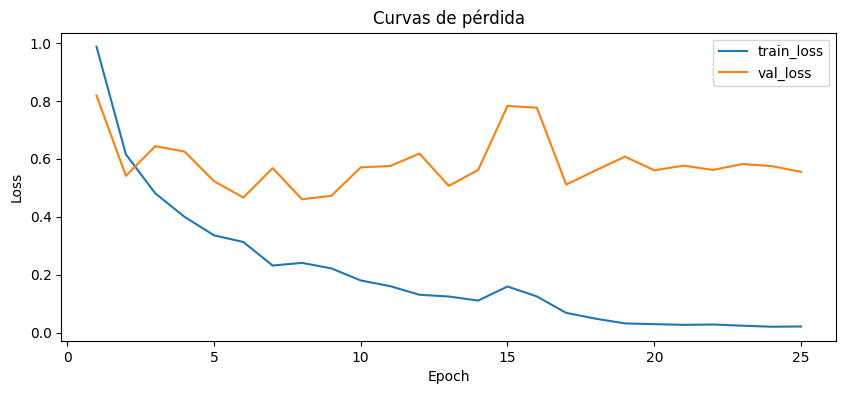

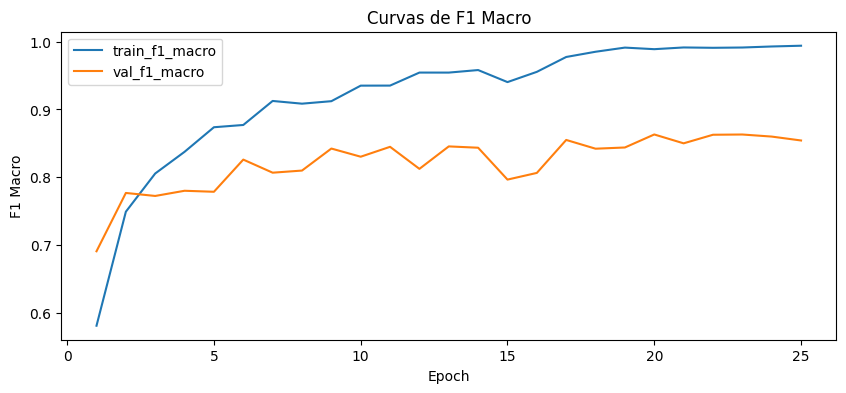

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curvas de pérdida")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["train_f1_macro"], label="train_f1_macro")
plt.plot(history_df["epoch"], history_df["val_f1_macro"], label="val_f1_macro")
plt.xlabel("Epoch")
plt.ylabel("F1 Macro")
plt.title("Curvas de F1 Macro")
plt.legend()
plt.show()

## Evaluación en test

In [17]:
test_metrics = run_one_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    optimizer=None,
    scaler=None,
    device=DEVICE
)

print("Resultados en test:")
print(f"test_loss     = {test_metrics['loss']:.4f}")
print(f"test_acc      = {test_metrics['acc']:.4f}")
print(f"test_f1_macro = {test_metrics['f1_macro']:.4f}")
print(f"test_f1_micro = {test_metrics['f1_micro']:.4f}")

/tmp/ipykernel_7608/3798974346.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda" and USE_MIXED_PRECISION)):


Resultados en test:
test_loss     = 0.5530
test_acc      = 0.8615
test_f1_macro = 0.8691
test_f1_micro = 0.8615


## Reporte de clasificación

In [18]:
target_names = [idx_to_label[i] for i in range(len(idx_to_label))]

report = classification_report(
    test_metrics["targets"],
    test_metrics["preds"],
    target_names=target_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

           0       0.84      0.91      0.88       197
           1       0.81      0.80      0.80       190
           2       0.84      0.80      0.82       115
           3       0.91      0.86      0.88       111
           4       0.96      0.96      0.96       102

    accuracy                           0.86       715
   macro avg       0.87      0.87      0.87       715
weighted avg       0.86      0.86      0.86       715



## Matriz de confusión

,0,1,2,3,4
0,179,16,2,0,0
1,28,152,7,3,0
2,3,15,92,4,1
3,2,4,7,95,3
4,0,1,1,2,98


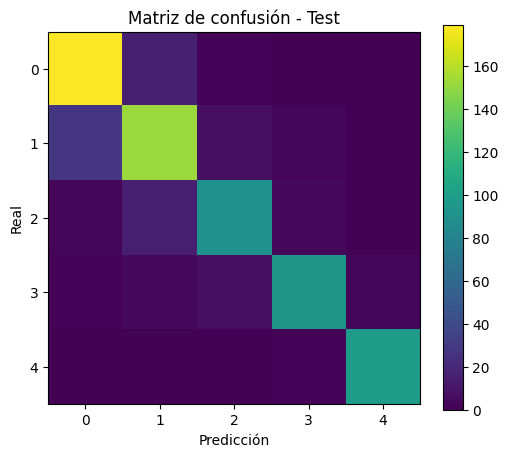

In [19]:
cm = confusion_matrix(test_metrics["targets"], test_metrics["preds"])
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

display(cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de confusión - Test")
plt.colorbar()
plt.xticks(ticks=np.arange(len(target_names)), labels=target_names)
plt.yticks(ticks=np.arange(len(target_names)), labels=target_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## Guardar artefactos

In [20]:
history_path = OUTPUT_DIR / "history.csv"
checkpoint_path = OUTPUT_DIR / "best_model.pt"
metrics_path = OUTPUT_DIR / "test_metrics.json"
cm_path = OUTPUT_DIR / "confusion_matrix.csv"
config_path = OUTPUT_DIR / "train_config.json"

history_df.to_csv(history_path, index=False)
torch.save(best_model_state, checkpoint_path)
cm_df.to_csv(cm_path, index=True)

metrics_dict = {
    "best_epoch": int(best_epoch),
    "best_val_f1_macro": float(best_val_f1_macro),
    "test_loss": float(test_metrics["loss"]),
    "test_acc": float(test_metrics["acc"]),
    "test_f1_macro": float(test_metrics["f1_macro"]),
    "test_f1_micro": float(test_metrics["f1_micro"]),
}

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=2)

config_dict = {
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "use_clahe": USE_CLAHE,
    "clahe_clip_limit": CLAHE_CLIP_LIMIT,
    "clahe_tile_grid_size": list(CLAHE_TILE_GRID_SIZE),
    "use_train_aug": USE_TRAIN_AUG,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
    "model_name": MODEL_NAME,
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_dict, f, ensure_ascii=False, indent=2)

print("Guardado en:")
print("-", history_path)
print("-", checkpoint_path)
print("-", metrics_path)
print("-", cm_path)
print("-", config_path)

Guardado en:
- /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/osteo_baseline/history.csv
- /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/osteo_baseline/best_model.pt
- /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/osteo_baseline/test_metrics.json
- /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/osteo_baseline/confusion_matrix.csv
- /mnt/d/Universidad/analitica/proyecto_analitica2/outputs/osteo_baseline/train_config.json
